## 2. Dataset overview

In [93]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



species_df = pd.read_csv("Castor fiber.csv", low_memory=False)
habitat_df = pd.read_csv("habitats_cbs_2022.csv")

df = species_df.merge(
    habitat_df,
    on=["decimalLongitude", "decimalLatitude"],
    how="left"
)


In [94]:
df.info()
df.describe()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 15 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Castor fiber               str    
 6   agricultural               float64
 7   built                      float64
 8   coast                      float64
 9   forest                     float64
 10  other                      float64
 11  sand/heather               float64
 12  water                      float64
 13  wetland                    float64
 14  main_habitat               str    
dtypes: float64(11), int64(1), str(3)
memory usage: 1.4 GB


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Castor fiber,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
1,50.75,5.65,2010-01-02,26.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
2,50.75,5.65,2010-01-03,3.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
3,50.75,5.65,2010-01-04,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
4,50.75,5.65,2010-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural


In [95]:
#Check duplicates
df.duplicated().sum()

np.int64(0)

In [96]:
# missing values
missing_values = df.isna().sum()
missing_values[missing_values > 0]


total_observations     4
agricultural          30
built                 30
coast                 30
forest                30
other                 30
sand/heather          30
water                 30
wetland               30
main_habitat          30
dtype: int64

In [97]:
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent[missing_percent > 0]

total_observations    0.000032
agricultural          0.000239
built                 0.000239
coast                 0.000239
forest                0.000239
other                 0.000239
sand/heather          0.000239
water                 0.000239
wetland               0.000239
main_habitat          0.000239
dtype: float64

In [98]:
habitat_cols = [
    "agricultural", "built", "coast", "forest", "other",
    "sand/heather", "water", "wetland", "main_habitat"
]

df = df.dropna(subset=habitat_cols)
df = df.dropna(subset=["total_observations"])

df.isna().sum()

decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           0
speciesgroup_observations    0
Castor fiber                 0
agricultural                 0
built                        0
coast                        0
forest                       0
other                        0
sand/heather                 0
water                        0
wetland                      0
main_habitat                 0
dtype: int64

In [99]:
df.dtypes

decimalLatitude              float64
decimalLongitude             float64
eventDate                        str
total_observations           float64
speciesgroup_observations      int64
Castor fiber                     str
agricultural                 float64
built                        float64
coast                        float64
forest                       float64
other                        float64
sand/heather                 float64
water                        float64
wetland                      float64
main_habitat                     str
dtype: object

In [100]:

df["eventDate"] = pd.to_datetime(df["eventDate"], errors="coerce")
df["Castor fiber"] = pd.to_numeric(df["Castor fiber"], errors="coerce")

In [101]:
df.dtypes

decimalLatitude                     float64
decimalLongitude                    float64
eventDate                    datetime64[us]
total_observations                  float64
speciesgroup_observations             int64
Castor fiber                          int64
agricultural                        float64
built                               float64
coast                               float64
forest                              float64
other                               float64
sand/heather                        float64
water                               float64
wetland                             float64
main_habitat                            str
dtype: object

In [102]:
(df[observation_cols] < 0).sum()

total_observations           0
speciesgroup_observations    0
Castor fiber                 0
dtype: int64

In [110]:
impossible_castor = df[df["Castor fiber"] > df["total_observations"]]
len(impossible_castor)

3722

In [111]:
df = df[df["Castor fiber"] <= df["total_observations"]]

In [112]:
(df["Castor fiber"] > df["total_observations"]).sum()

np.int64(0)

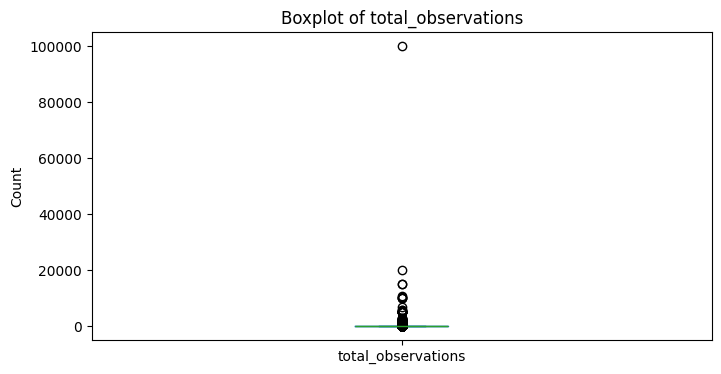

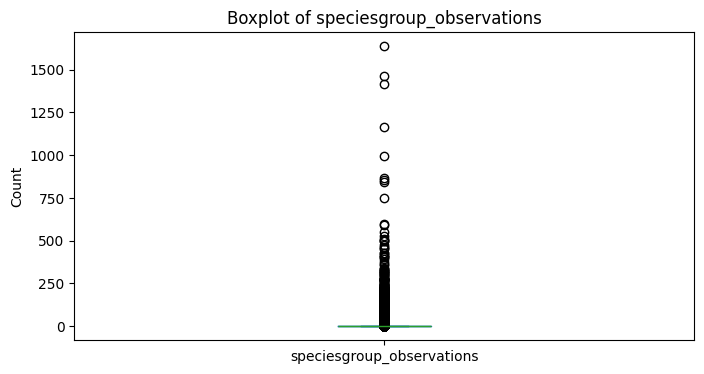

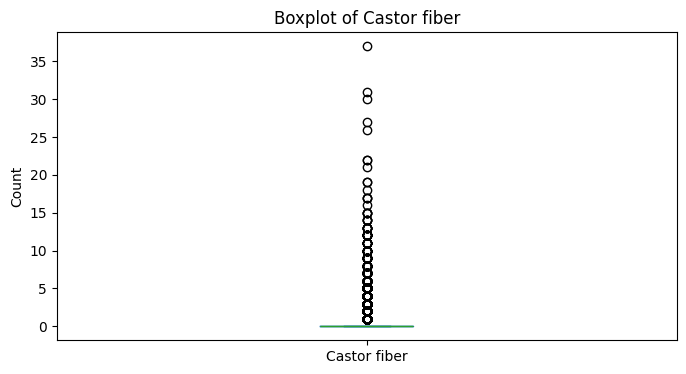

In [120]:
import matplotlib.pyplot as plt

for col in observation_cols:
    plt.figure(figsize=(8, 4))
    df[col].plot(kind="box")
    plt.title(f"Boxplot of {col}")
    plt.ylabel("Count")
    plt.show()

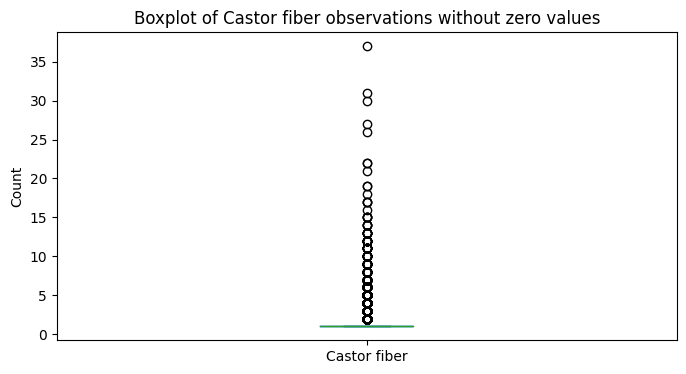

In [121]:
import matplotlib.pyplot as plt

castor_nonzero = df[df["Castor fiber"] > 0]

plt.figure(figsize=(8, 4))
castor_nonzero["Castor fiber"].plot(kind="box")
plt.title("Boxplot of Castor fiber observations without zero values")
plt.ylabel("Count")
plt.show()

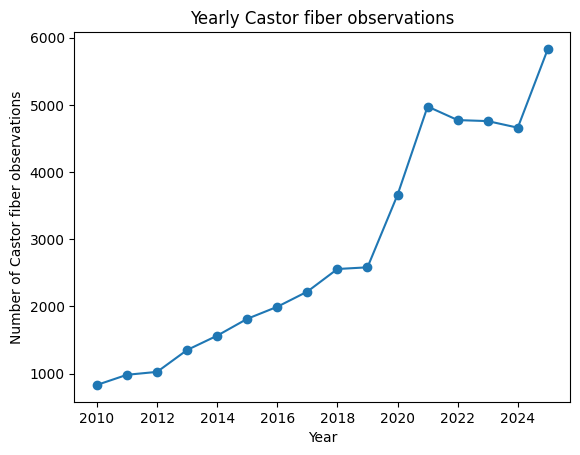

In [118]:
yearly_castor = df.groupby("year")["Castor fiber"].sum()

yearly_castor.plot(kind="line", marker="o")
plt.title("Yearly Castor fiber observations")
plt.xlabel("Year")
plt.ylabel("Number of Castor fiber observations")
plt.show()

In [123]:
df.describe()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Castor fiber,agricultural,built,coast,forest,other,sand/heather,water,wetland,year
count,1.255503e+07,1.255503e+07,12555034,1.255503e+07,1.255503e+07,1.255503e+07,1.255503e+07,1.255503e+07,1.255503e+07,1.255503e+07,1.255503e+07,1.255503e+07,1.255503e+07,1.255503e+07,1.255503e+07
mean,5.223021e+01,5.532764e+00,2017-12-31 11:55:32.859220,8.117134e+00,2.217053e-01,3.632328e-03,9.452341e+00,2.404731e+00,1.303313e+00,1.621167e+00,1.501417e+00,1.881924e-01,1.245386e+00,2.249782e-01,2.017500e+03
min,5.075000e+01,3.350000e+00,2010-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.010000e+03
25%,5.170000e+01,4.900000e+00,2013-12-31 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,5.348400e+00,7.667000e-01,0.000000e+00,1.494000e-01,7.249000e-01,0.000000e+00,9.900000e-02,0.000000e+00,2.013000e+03
50%,5.220000e+01,5.650000e+00,2018-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00,1.056820e+01,1.559900e+00,0.000000e+00,7.092000e-01,1.199800e+00,0.000000e+00,3.102000e-01,1.820000e-02,2.018000e+03
75%,5.280000e+01,6.200000e+00,2022-01-01 00:00:00,6.000000e+00,0.000000e+00,0.000000e+00,1.380080e+01,3.291600e+00,0.000000e+00,2.036400e+00,2.006500e+00,2.340000e-02,1.033000e+00,1.417000e-01,2.022000e+03
max,5.350000e+01,7.200000e+00,2025-12-31 00:00:00,1.000400e+05,1.637000e+03,3.700000e+01,1.810460e+01,1.435380e+01,1.934870e+01,1.699850e+01,1.039830e+01,1.034430e+01,1.890870e+01,1.422410e+01,2.025000e+03
std,6.604851e-01,8.749625e-01,NaN,3.920749e+01,1.974920e+00,8.679620e-02,5.148154e+00,2.419834e+00,3.970737e+00,2.385907e+00,1.167861e+00,7.710884e-01,2.688250e+00,7.063856e-01,4.609765e+00
